

## Predict Product Prices

### And now, to evaluate our fine-tuned open source model



In [1]:
# pip installs

#!pip install -q --upgrade torch==2.5.1+cu124 torchvision==0.20.1+cu124 torchaudio==2.5.1+cu124 --index-url https://download.pytorch.org/whl/cu124
#!pip install -q --upgrade requests==2.32.3 bitsandbytes==0.46.0 transformers==4.48.3 accelerate==1.3.0 datasets==3.2.0 peft==0.14.0 trl==0.14.0 matplotlib wandb

In [2]:
# imports

import os
import re
import math
from tqdm import tqdm
#from google.colab import userdata
from huggingface_hub import login
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
from peft import PeftModel
import matplotlib.pyplot as plt

In [3]:
# Constants

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
PROJECT_NAME = "pricer"
HF_USER = "ed-donner" # your HF name here! Or use mine if you just want to reproduce my results.
HF_USER = "sergio-sanz-rodriguez"

# The run itself

RUN_NAME = "2024-09-13_13.04.39"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
REVISION = "e8d637df551603dc86cd7a1598a8f44af4d7ae36" # or REVISION = None
#FINETUNED_MODEL = f"{HF_USER}/{PROJECT_RUN_NAME}"

#RUN_NAME = "2025-07-07_13.12.02"
#RUN_NAME = "2025-07-08_22.49.30"
#PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
#REVISION = "32ecc2e144029b73b8aa9df4cbe59a43de04b7df"
#REVISION = "1cdb339cef8cbbd1039a1f0966499ebc86d1008f"
#REVISION = "32ecc2e144029b73b8aa9df4cbe59a43de04b7df"
REVISION = None
FINETUNED_MODEL = f"{HF_USER}/{PROJECT_RUN_NAME}"

# Uncomment this line if you wish to use my model
FINETUNED_MODEL = f"ed-donner/{PROJECT_RUN_NAME}"

# Data

DATASET_NAME = f"{HF_USER}/pricer-data"
# Or just use the one I've uploaded
#DATASET_NAME = "ed-donner/pricer-data"

# Hyperparameters for QLoRA

QUANT_4_BIT = True

%matplotlib inline

# Used for writing to output in color

GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

### Log in to HuggingFace

If you don't already have a HuggingFace account, visit https://huggingface.co to sign up and create a token.

Then select the Secrets for this Notebook by clicking on the key icon in the left, and add a new secret called `HF_TOKEN` with the value as your token.


In [4]:
# Log in to HuggingFace

#hf_token = userdata.get('HF_TOKEN')
#login(hf_token, add_to_git_credential=True)

from dotenv import load_dotenv
load_dotenv(override=True)
hf_token = os.environ['HF_TOKEN3']
#hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

In [6]:
test[0]

{'text': 'How much does this cost to the nearest dollar?\n\nNavePoint 4ft Open Frame 19 Inch 22U 4-Post Network Server Relay Rack Rolling with Casters\nThis 4-post open frame adjustable depth rack by NavePoint is great for organizing your networking equipment. Comes flat-packed and requires some assembly. Made of high-quality SPCC Cold Rolled Steel with a powdered coated finish for durability. The rack comes equipped with casters for easy movement and relocation of equipment. Available in a variety heights. 4-post Open Frame Rack Includes casters (can also floor mount) Supports standard 19 rack mount equipment 44.02 H x 59.2 W x 60 D Rack Depth 9.45 - 15.75 (adjusts in 1.5 increments) Dimensions 61 x 12 x \n\nPrice is $',
 'price': 250.56}

## Now load the Tokenizer and Model

In [7]:
# pick the right quantization (thank you Robert M. for spotting the bug with the 8 bit version!)

if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  quant_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

In [8]:
# Load the Tokenizer and the Model

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id

# Load the fine-tuned model with PEFT
if REVISION:
  fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL, revision=REVISION, token=hf_token)
else:
  fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL, token=hf_token)
  #fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL)


print(f"Memory footprint: {fine_tuned_model.get_memory_footprint() / 1e6:.1f} MB")

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Memory footprint: 5700.6 MB


In [9]:
fine_tuned_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora

# THE MOMENT OF TRUTH!

## Use the model in inference mode

Remember, GPT-4o had an average error of \$76.  
Llama 3.1 base model had an average error of \$396.   
This human had an error of \$127.  

## Caveat

Keep in mind that prices of goods vary considerably; the model can't predict things like sale prices that it doesn't have any information about.

In [10]:
def extract_price(s):
    if "Price is $" in s:
      contents = s.split("Price is $")[1]
      contents = contents.replace(',','')
      match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
      return float(match.group()) if match else 0
    return 0

In [11]:
extract_price("Price is $a fabulous 899.99 or so")

899.99

In [12]:
# Original prediction function takes the most likely next token

def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda")
    attention_mask = torch.ones(inputs.shape, device="cuda")
    outputs = fine_tuned_model.generate(inputs, attention_mask=attention_mask, max_new_tokens=3, num_return_sequences=1)
    response = tokenizer.decode(outputs[0])
    return extract_price(response)

In [13]:
# An improved prediction function takes a weighted average of the top 3 choices
# This code would be more complex if we couldn't take advantage of the fact
# That Llama generates 1 token for any 3 digit number

top_K = 3

def improved_model_predict(prompt, device="cuda"):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)
    attention_mask = torch.ones(inputs.shape, device=device)

    with torch.no_grad():
        outputs = fine_tuned_model(inputs, attention_mask=attention_mask)
        next_token_logits = outputs.logits[:, -1, :].to('cpu')

    next_token_probs = F.softmax(next_token_logits, dim=-1)
    top_prob, top_token_id = next_token_probs.topk(top_K)
    prices, weights = [], []
    for i in range(top_K):
      predicted_token = tokenizer.decode(top_token_id[0][i])
      probability = top_prob[0][i]
      try:
        result = float(predicted_token)
      except ValueError as e:
        result = 0.0
      if result > 0:
        prices.append(result)
        weights.append(probability)
    if not prices:
      return 0.0, 0.0
    total = sum(weights)
    weighted_prices = [price * weight / total for price, weight in zip(prices, weights)]
    return sum(weighted_prices).item()

In [14]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error<40 or error/truth < 0.2:
            return "green"
        elif error<80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])
        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

1: Guess: $224.38 Truth: $250.56 Error: $26.19 SLE: 0.01 Item: NavePoint 4ft Open F...
2: Guess: $226.25 Truth: $232.18 Error: $5.93 SLE: 0.00 Item: APS Premium 6in iBoa...
3: Guess: $162.00 Truth: $134.87 Error: $27.13 SLE: 0.03 Item: Peerless Tub and Sho...
4: Guess: $335.50 Truth: $357.09 Error: $21.59 SLE: 0.00 Item: TransDeco TD600B Sta...
5: Guess: $50.69 Truth: $258.07 Error: $207.38 SLE: 2.60 Item: ACDelco Professional...
6: Guess: $38.97 Truth: $27.95 Error: $11.02 SLE: 0.10 Item: AutoStuff - Camisasc...
7: Guess: $172.12 Truth: $170.99 Error: $1.13 SLE: 0.00 Item: HJC Helmets Unisex-A...
8: Guess: $173.50 Truth: $225.00 Error: $51.50 SLE: 0.07 Item: Magnetic Roller Tip ...
9: Guess: $122.62 Truth: $105.09 Error: $17.53 SLE: 0.02 Item: Linksys by Cisco Wir...
10: Guess: $299.00 Truth: $299.99 Error: $0.99 SLE: 0.00 Item: PEDAL COMMANDER for ...
11: Guess: $435.50 Truth: $534.95 Error: $99.45 SLE: 0.04 Item: SuperATV Dark Tinted...
12: Guess: $10.09 Truth: $12.45 Error: $2.36 S

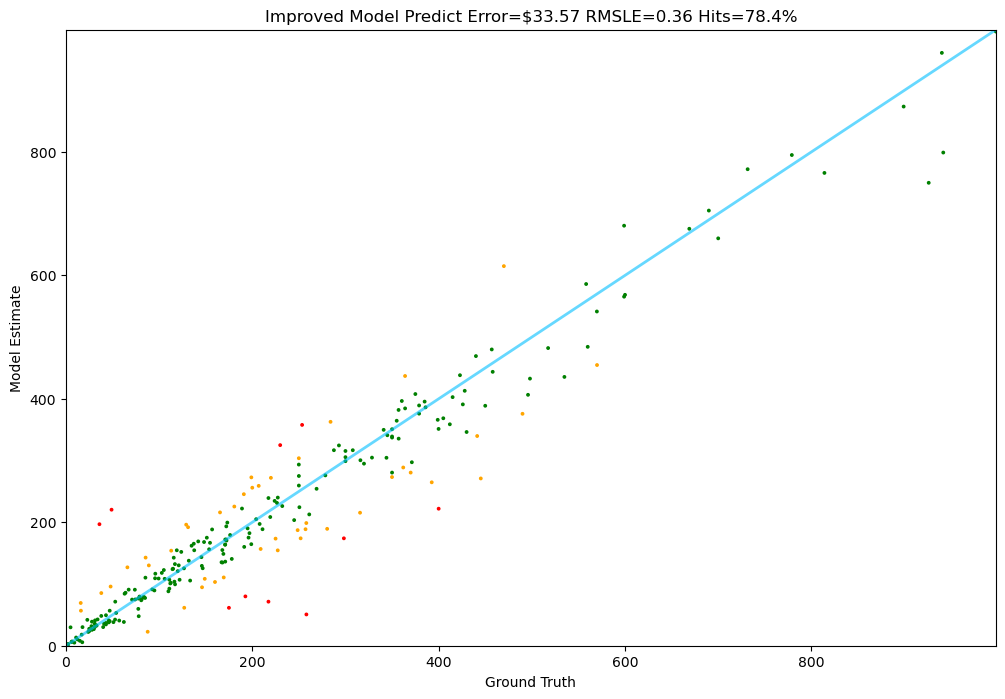

In [15]:
Tester.test(improved_model_predict, test)